# Customer Segmentation Using Unsupervised Learning

## Introduction

Customer segmentation is a data-driven technique used to group customers with similar characteristics and purchasing behavior. It enables businesses to better understand their customers, create targeted marketing campaigns, improve customer satisfaction, and optimize business strategies.

In this project, customer segmentation is performed using the K-Means clustering algorithm on the Mall Customers dataset. The analysis includes exploratory data analysis (EDA), dimensionality reduction using Principal Component Analysis (PCA), cluster visualization, and marketing strategy recommendations for each customer segment.

## Problem Statement

Businesses often serve customers with different spending behaviors, income levels, and purchasing patterns. Applying the same marketing strategy to every customer may reduce marketing effectiveness and customer engagement.

To support data-driven decision-making, customers need to be segmented into meaningful groups based on their characteristics. These segments help businesses understand customer behavior and design personalized marketing strategies for different customer groups.

## Project Objectives

The main objectives of this project are:

- Perform Exploratory Data Analysis (EDA).
- Segment customers using the K-Means clustering algorithm.
- Determine the optimal number of customer clusters.
- Visualize customer segments using Principal Component Analysis (PCA).
- Analyze the characteristics of each customer segment.
- Recommend marketing strategies based on the identified customer segments.

## Dataset Information

This project uses the **Mall Customers Dataset**, which is widely used for customer segmentation and unsupervised learning tasks.

**Dataset Source:**  
https://www.kaggle.com/datasets/shwetabh123/mall-customers

The dataset contains demographic information and spending behavior of mall customers.

The primary objective of this dataset is to identify groups of customers with similar characteristics based on their demographic attributes and spending patterns.

Each record represents an individual customer and includes information such as gender, age, annual income, and spending score assigned by the shopping mall.

This dataset is well suited for clustering techniques such as **K-Means**, allowing businesses to identify distinct customer segments and develop targeted marketing strategies.

### Dataset Summary

| Attribute | Description |
|------------|-------------|
| Dataset Name | Mall Customers Dataset |
| Source | Kaggle |
| File Used | Mall_Customers.csv |
| Problem Type | Unsupervised Learning (Clustering) |
| Algorithm | K-Means Clustering |
| Domain | Retail and Marketing |

### Dataset Features

| Feature | Description |
|----------|-------------|
| CustomerID | Unique identifier for each customer |
| Gender | Customer gender (Male/Female) |
| Age | Customer age (years) |
| Annual Income (k$) | Annual income in thousand dollars |
| Spending Score (1–100) | Spending score assigned by the mall |

## Import Required Libraries

Before starting the analysis, the required Python libraries are imported.

These libraries are used for data manipulation, visualization, preprocessing, clustering, and dimensionality reduction throughout the project.

- **Pandas** and **NumPy** are used for data manipulation and numerical computations.
- **Matplotlib** and **Seaborn** are used for data visualization.
- **Scikit-learn** is used for feature scaling, K-Means clustering, and Principal Component Analysis (PCA).

In [2]:
# Data Manipulation

import pandas as pd
import numpy as np

# Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing

from sklearn.preprocessing import StandardScaler

# Machine Learning

from sklearn.cluster import KMeans

# Dimensionality Reduction

from sklearn.decomposition import PCA

## Load Dataset

The Mall Customers dataset is loaded into a Pandas DataFrame for analysis.

In [3]:
# Load the dataset

df = pd.read_csv("../dataset/Mall_Customers.csv")

## Dataset Preview

After loading the dataset, the first few records are displayed to verify that the dataset has been loaded correctly and to gain an initial understanding of its structure.

In [4]:
# Display the first five records

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Data Cleaning and Preprocessing

Data cleaning is an essential step before performing exploratory data analysis and clustering.

In this phase, the dataset is examined for missing values, duplicate records, data types, and overall data quality to ensure it is suitable for customer segmentation.

### Dataset Shape

The shape of the dataset is examined to determine the total number of records and features available for analysis.

In [5]:
# Display dataset shape

df.shape

(200, 5)

#### Observation

The dataset contains **200 customer records** and **5 features**, providing sufficient information for customer segmentation using unsupervised learning techniques.

### Dataset Information

The dataset information is examined to understand the structure of the dataset, including column names, data types, and non-null values.

In [6]:
# Display dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


#### Observation

The dataset contains **200 records** and **5 features**. All columns have **200 non-null values**, indicating that there are no missing values. The dataset consists of one categorical feature and four numerical features, making it suitable for exploratory data analysis and customer segmentation.

### Duplicate Records

Duplicate records are examined to ensure that each customer is represented only once in the dataset. Removing duplicate entries helps maintain data quality and prevents biased clustering results.

In [7]:
# Check duplicate records

print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


#### Observation

No duplicate records were found in the dataset. The dataset is ready for further analysis without removing any duplicate observations.

### Descriptive Statistics

Descriptive statistics provide a statistical summary of the numerical features, including measures such as count, mean, standard deviation, minimum, maximum, and quartiles.

This summary helps understand the distribution and variation of numerical variables before performing exploratory data analysis and clustering.

In [8]:
# Display descriptive statistics

df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


#### Observation

The dataset contains **200 customer records**. The average customer age is **38.85 years**, while the average annual income is **60.56 thousand dollars**. The average spending score is **50.20**, indicating a balanced distribution of customer spending behavior. Overall, the numerical features show sufficient variation for meaningful customer segmentation.

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand customer demographics and spending behavior through statistical summaries and visualizations.

The insights obtained during this phase help identify meaningful patterns in the data before applying K-Means clustering for customer segmentation.

### Gender Distribution

The distribution of customer gender is analyzed to understand the proportion of male and female customers in the dataset.

In [9]:
# Display gender distribution

df["Genre"].value_counts()

Genre
Female    112
Male       88
Name: count, dtype: int64

#### Gender Distribution Visualization

A count plot is used to visualize the distribution of male and female customers in the dataset.

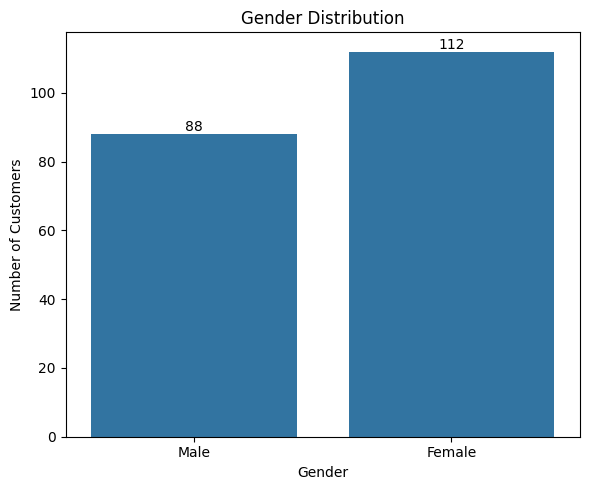

In [10]:
# Plot gender distribution

plt.figure(figsize=(6,5))

ax=sns.countplot(
    data=df,
    x="Genre",
)

# Add value labels
ax.bar_label(ax.containers[0])

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.tight_layout()

# Save figure
# plt.savefig(
#     "../outputs/figures/01_gender_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

##### Observation

The dataset contains **112 female customers** and **88 male customers**. Female customers slightly outnumber male customers, although the overall gender distribution is relatively balanced.

### Age Distribution

The age distribution of customers is analyzed to understand the demographic composition of the customer base and identify the most common age groups.

#### Age Distribution Histogram

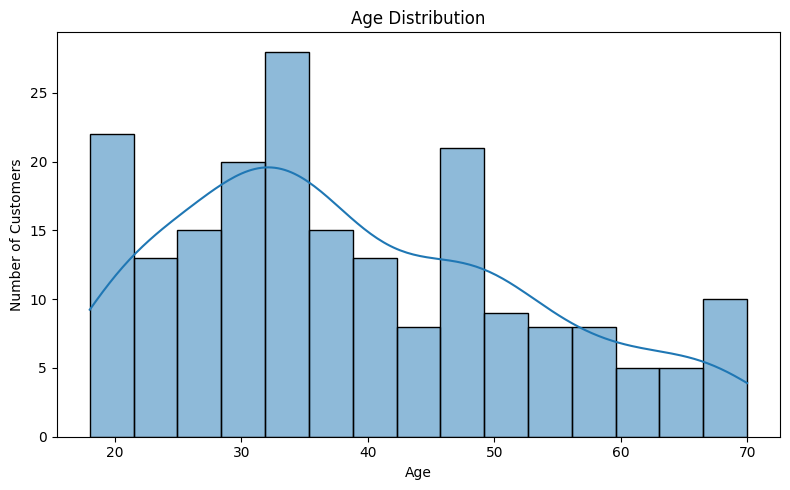

In [11]:
# Plot age distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Age",
    bins=15,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.tight_layout()

# plt.savefig(
#     "../outputs/figures/02_age_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

#### Age Distribution Box Plot

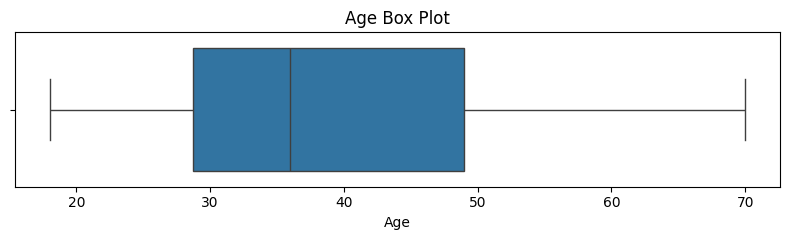

In [12]:
# Plot age box plot

plt.figure(figsize=(8, 2.5))

sns.boxplot(
    data=df,
    x="Age"
)

plt.title("Age Box Plot")
plt.xlabel("Age")

plt.tight_layout()

# plt.savefig(
#     "../outputs/figures/03_age_boxplot.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

#### Observation

Most customers are between **25 and 40 years** of age, with the highest concentration around the early 30s. The number of customers gradually decreases as age increases, indicating that the mall primarily attracts young and middle-aged customers. The box plot shows **no significant outliers**, suggesting that the age data is well distributed and suitable for customer segmentation.

### Annual Income Distribution

The distribution of annual income is analyzed to understand the income levels of customers and identify the spread of income across the dataset.

#### Annual Income Distribution Histogram

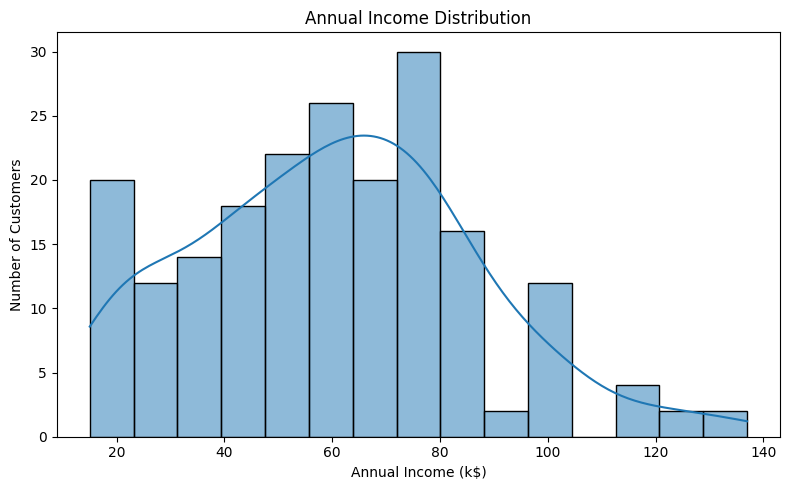

In [13]:
# Plot annual income distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Annual Income (k$)",
    bins=15,
    kde=True
)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")

plt.tight_layout()

# plt.savefig(
#     "../outputs/figures/04_annual_income_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

#### Annual Income Distribution Box Plot

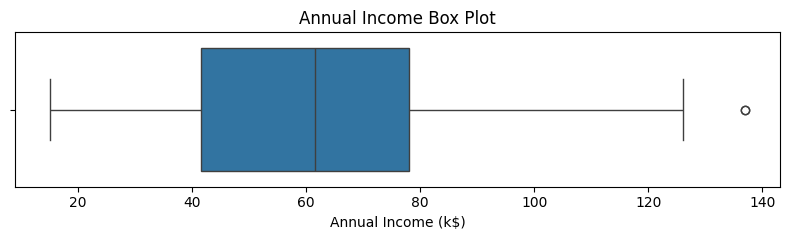

In [14]:
# Plot annual income box plot

plt.figure(figsize=(8, 2.5))

sns.boxplot(
    data=df,
    x="Annual Income (k$)"
)

plt.title("Annual Income Box Plot")
plt.xlabel("Annual Income (k$)")

plt.tight_layout()

# plt.savefig(
#     "../outputs/figures/05_annual_income_boxplot.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

#### Observation

Most customers have an annual income between **40 thousand and 80 thousand dollars**, with the highest concentration around **60 thousand to 75 thousand dollars**. The number of customers decreases at higher income levels, indicating that relatively few customers have very high annual incomes. The box plot reveals **one potential high-income outlier**, suggesting the presence of a small number of customers with exceptionally high annual incomes.

### Spending Score Distribution

The distribution of customer spending scores is analyzed to understand customer purchasing behavior and identify how spending patterns vary across the dataset.

#### Spending Score Distribution Histogram

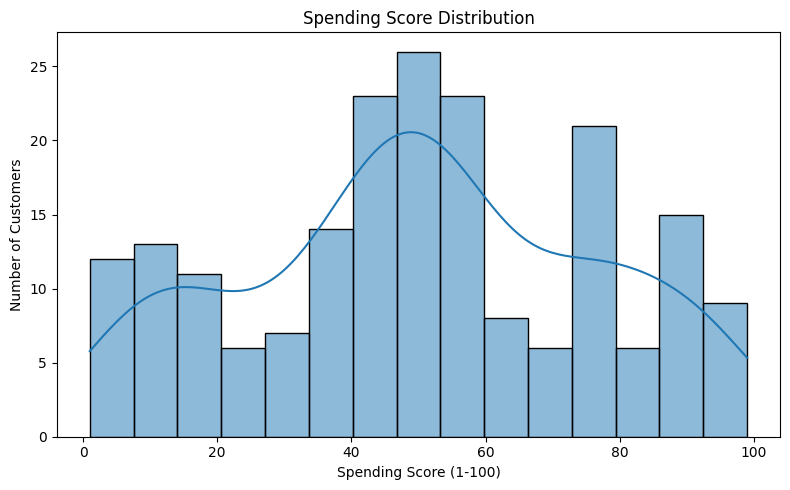

In [15]:
# Plot spending score distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Spending Score (1-100)",
    bins=15,
    kde=True
)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score (1-100)")
plt.ylabel("Number of Customers")

plt.tight_layout()

# plt.savefig(
#     "../outputs/figures/06_spending_score_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

#### Spending Score Distribution Box Plot

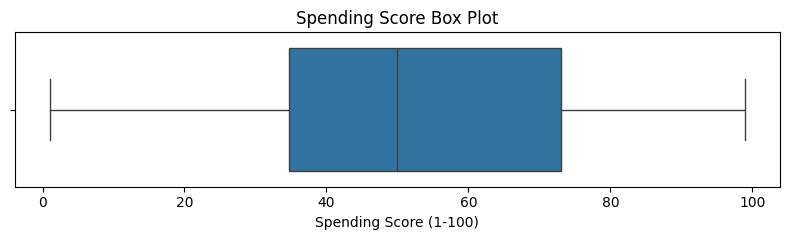

In [16]:
# Plot spending score box plot

plt.figure(figsize=(8, 2.5))

sns.boxplot(
    data=df,
    x="Spending Score (1-100)"
)

plt.title("Spending Score Box Plot")
plt.xlabel("Spending Score (1-100)")

plt.tight_layout()

# plt.savefig(
#     "../outputs/figures/07_spending_score_boxplot.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

#### Observation

Most customers have a **moderate spending score**, with the highest concentration between **40 and 60**. The spending scores are distributed across the entire range, indicating that the dataset includes customers with both low and high spending behavior. The box plot shows **no significant outliers**, suggesting that the spending score data is well distributed and suitable for customer segmentation.

## Relationship Between Features

To better understand customer behavior, relationships between key variables are analyzed. This helps identify patterns that may support meaningful customer segmentation using clustering techniques.

### Annual Income vs Spending Score

The relationship between annual income and spending score is analyzed to understand how customer spending behavior varies across different income levels.

#### Annual Income vs Spending Score Scatter Plot

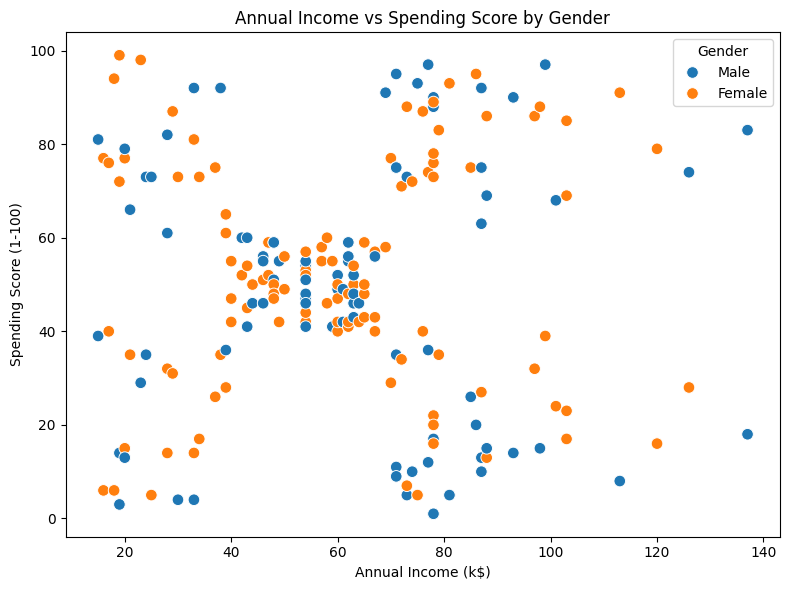

In [17]:
# Plot annual income vs spending score

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Genre",
    s=70
)

plt.title("Annual Income vs Spending Score by Gender")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Gender")

plt.tight_layout()

# plt.savefig(
#     "../outputs/figures/08_annual_income_vs_spending_score.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

#### Observation

The scatter plot shows that both **male** and **female** customers are distributed across a wide range of annual income and spending score values. Customers with similar income levels exhibit different spending behaviors regardless of gender, indicating that annual income alone does not determine customer spending patterns. The visible grouping of customers suggests that **Annual Income** and **Spending Score** are effective features for identifying distinct customer segments using **K-Means clustering**.

### Age vs Spending Score

The relationship between customer age and spending score is analyzed to examine how purchasing behavior varies across different age groups.

#### Age vs Spending Score Scatter Plot

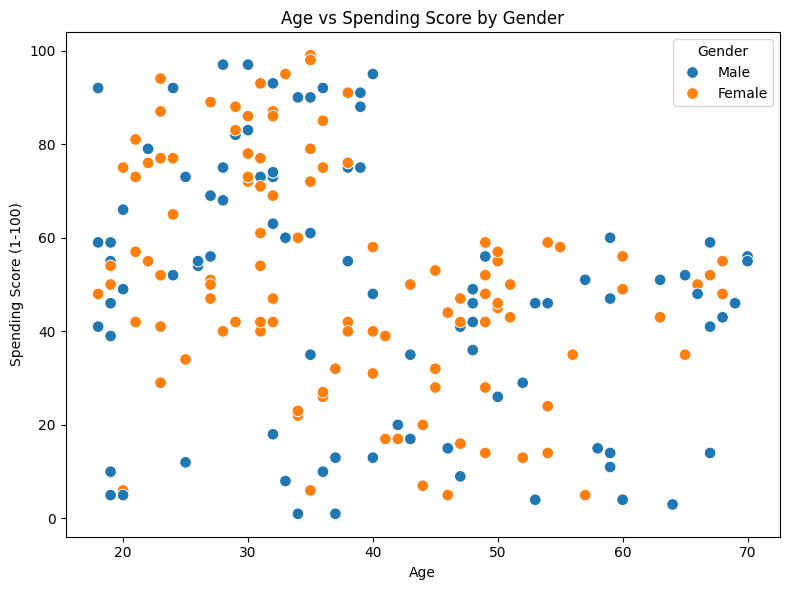

In [18]:
# Plot age vs spending score

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Spending Score (1-100)",
    hue="Genre",
    s=70
)

plt.title("Age vs Spending Score by Gender")
plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Gender")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/09_age_vs_spending_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation

The scatter plot indicates that both **male** and **female** customers are represented across all age groups and spending score levels. Younger customers (approximately **18–40 years**) exhibit a wider variation in spending behavior, ranging from very low to very high spending scores. In contrast, customers above **40 years** generally show more moderate spending patterns. These findings suggest that **Age** is an important feature for identifying distinct customer segments when combined with **Spending Score**.

### Correlation Analysis

Correlation analysis is performed to measure the strength and direction of relationships between numerical variables in the dataset.

#### Correlation Matrix

In [19]:
# Compute correlation matrix

correlation_matrix = df.drop(columns="CustomerID").corr(numeric_only=True)

# Display correlation matrix

correlation_matrix

,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000000,-0.012398,-0.327227
Annual Income (k$),-0.012398,1.000000,0.009903
Spending Score (1-100),-0.327227,0.009903,1.000000


#### Correlation Heatmap

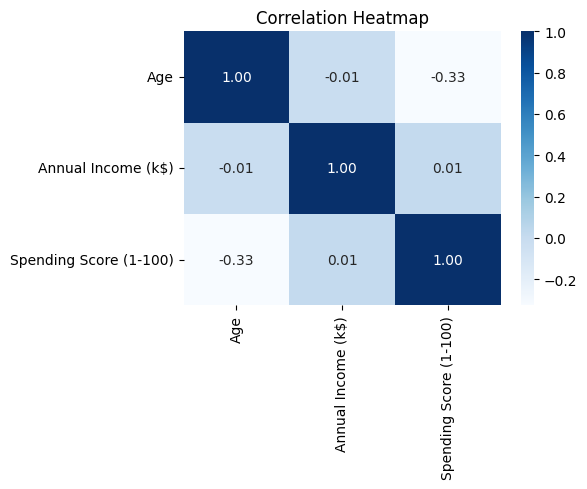

In [20]:
# Plot correlation heatmap

plt.figure(figsize=(6, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f" 
)

plt.title("Correlation Heatmap")

plt.tight_layout()

# Save figure

# plt.savefig(
#     "../outputs/figures/10_correlation_heatmap.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

#### Observation

The correlation heatmap indicates a **moderate negative correlation (-0.33)** between **Age** and **Spending Score**, suggesting that spending behavior generally decreases as customer age increases. In contrast, **Annual Income** has almost no correlation with either **Age (-0.01)** or **Spending Score (0.01)**, indicating that these variables are largely independent. Overall, the weak correlations suggest that customer behavior cannot be explained by a single feature alone, supporting the use of **K-Means clustering** to identify meaningful customer segments.

## Model Development

### Feature Selection

Feature selection is performed to choose the most relevant variables for customer segmentation.

For this project, **Annual Income (k$)** and **Spending Score (1–100)** are selected because they directly represent customers' purchasing capacity and spending behavior. These two features provide a clear basis for identifying distinct customer segments using the K-Means clustering algorithm.

The **CustomerID** column is excluded because it is only a unique identifier, while the **Genre** column is categorical and is not used in the clustering model.

In [21]:
# Select features for clustering

X = df[
    [
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]

# Display the first five records

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


#### Observation

The selected dataset contains only the two numerical features required for customer segmentation. These features capture customers' income and spending behavior and will be used as input for feature scaling and K-Means clustering.

### Feature Scaling

Feature scaling is performed to standardize the selected features before applying the K-Means clustering algorithm.

Since K-Means is a distance-based algorithm, variables with larger numerical ranges can have a greater influence on cluster formation. Standardizing the features ensures that each variable contributes equally during the clustering process.

In [22]:
# Initialize the scaler

scaler = StandardScaler()

# Standardize the selected features

X_scaled = scaler.fit_transform(X)

# Display the first five scaled records

pd.DataFrame(
    X_scaled,
    columns=X.columns
).head()

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


#### Observation

The selected features have been standardized using **StandardScaler**, transforming them to a common scale with a mean close to **0** and a standard deviation close to **1**. As a result, negative values represent observations below the feature mean, while positive values represent observations above the mean. This standardization ensures that both **Annual Income** and **Spending Score** contribute equally to the distance calculations performed by the K-Means clustering algorithm.

### Finding the Optimal Number of Clusters

Before training the K-Means clustering model, it is important to determine the optimal number of clusters (**K**).

The **Elbow Method** evaluates the Within-Cluster Sum of Squares (**WCSS**) for different values of **K**. As the number of clusters increases, WCSS decreases. The optimal value of **K** is identified at the point where the rate of decrease begins to slow down, forming an "elbow" in the curve.

In [23]:
# Initialize an empty list to store WCSS values

wcss = []

# Calculate WCSS for different values of K

for k in range(1, 11):
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

# Display WCSS values

wcss

[400.0,
 269.69101219276394,
 157.70400815035947,
 108.92131661364357,
 65.5684081557168,
 55.05734827038599,
 44.86475569922556,
 37.228187677585886,
 32.39226763033116,
 29.981897788243693]

#### Elbow Method Visualization

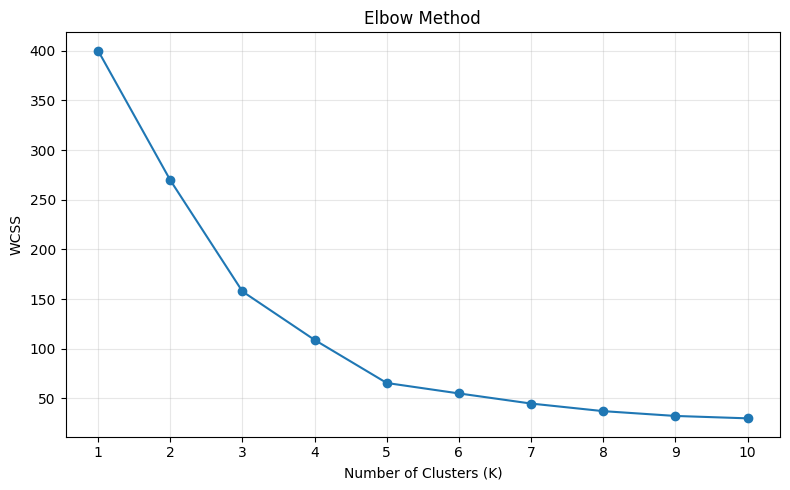

In [26]:
# Plot the Elbow Method

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.xticks(range(1,11))

plt.grid(alpha=0.3)

plt.tight_layout()

# plt.savefig(
#     "../outputs/figures/11_elbow_method.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

#### Observation

The WCSS decreases rapidly as the number of clusters increases from **K = 1** to **K = 5**, after which the rate of decrease becomes much smaller. The elbow point is observed at **K = 5**, indicating that five clusters provide a good balance between minimizing within-cluster variation and maintaining a simple clustering structure. Therefore, **K = 5** is selected as the optimal number of clusters for the K-Means model.

### K-Means Clustering

Based on the Elbow Method, the optimal number of clusters is determined to be **5**.

The K-Means algorithm is trained using the standardized features to group customers with similar spending behavior into distinct clusters.

In [27]:
# Train the K-Means model

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

# Fit the model

kmeans.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](5, 2)","[[-0.

#### Observation

The K-Means model has been successfully trained using **5 clusters** determined by the Elbow Method. The trained model is now ready to assign each customer to a cluster based on similarities in annual income and spending behavior.

### Assign Cluster Labels

After training the K-Means model, each customer is assigned to a cluster based on similarities in annual income and spending behavior.

The assigned cluster labels are added to the dataset, enabling further analysis, visualization, and the development of marketing strategies for each customer segment.

In [28]:
# Assign cluster labels to each customer

df["Cluster"] = kmeans.labels_

# Display the first five records

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


#### Observation

A new column named **Cluster** has been added to the dataset. Each customer has been assigned to one of the **five clusters (0–4)** based on similarities in annual income and spending behavior. These cluster labels will be used for customer segmentation, visualization, and marketing strategy development.

### Cluster Distribution

The number of customers in each cluster is examined to understand how customers are distributed across the identified segments.

In [29]:
# Display the number of customers in each cluster

df["Cluster"].value_counts().sort_index()

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

#### Observation

The customer distribution shows that the identified clusters contain different numbers of customers. **Cluster 0** is the largest segment with **81 customers**, while **Cluster 2** is the smallest with **22 customers**. This variation indicates that customer groups differ in size, suggesting that certain spending behaviors are more common than others.

### Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is applied to reduce the dimensionality of the standardized features while preserving most of the information contained in the original data.

Reducing the data to two principal components makes it possible to visualize customer segments in a two-dimensional space and evaluate the effectiveness of the K-Means clustering algorithm.

#### Apply PCA

In [30]:
# Initialize PCA with two principal components

pca = PCA(n_components=2)

# Transform the standardized features

X_pca = pca.fit_transform(X_scaled)

# Display the first five transformed records

pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
).head()

,PC1,PC2
0,-1.537109,-0.922207
1,-0.384168,-2.075149
2,-2.416002,0.010665
3,-0.466982,-1.938355
4,-1.455678,-0.895678


#### Observation

The standardized features have been successfully transformed into **two principal components (PC1 and PC2)** using Principal Component Analysis (PCA). These components preserve most of the variation present in the original features while reducing the data to two dimensions. The transformed data will be used to visualize the customer clusters identified by the K-Means algorithm.

#### PCA Cluster Visualization

The transformed principal components are visualized to examine how the identified customer segments are separated in the reduced two-dimensional feature space.

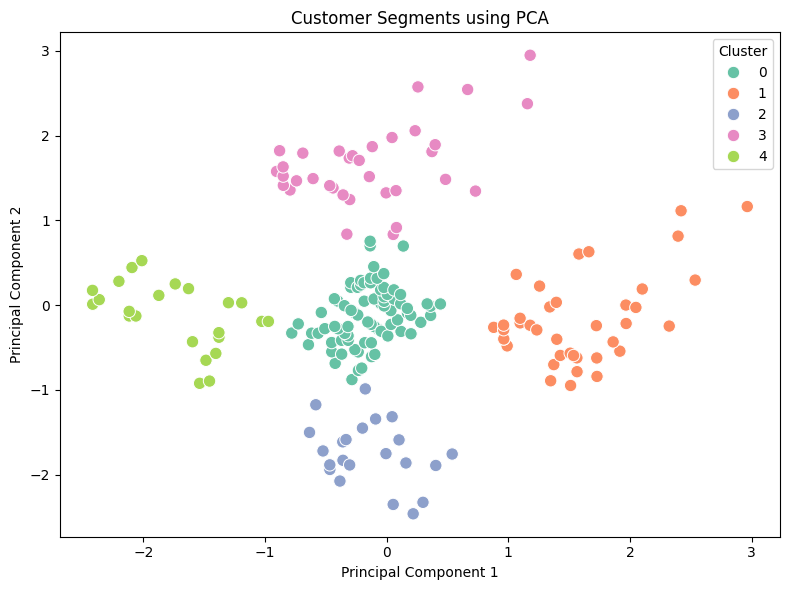

In [33]:
# Create a DataFrame for visualization

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

# Add cluster labels

pca_df["Cluster"] = kmeans.labels_

# Plot PCA clusters

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=80
)

plt.title("Customer Segments using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")

plt.tight_layout()

# plt.savefig(
#     "../outputs/figures/12_pca_cluster_visualization.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

#### Observation

The PCA visualization shows that the **K-Means algorithm has successfully divided the customers into five distinct segments**. Most clusters are well separated with only slight overlap near the center, indicating that the selected features effectively differentiate customer groups. The clear separation between clusters suggests that customers exhibit different spending patterns and income levels, making the segmentation suitable for targeted marketing strategies.

### Cluster Analysis

After identifying the customer segments, each cluster is analyzed to understand its characteristics. The average annual income and spending score of each cluster are examined to identify different customer profiles and support business decision-making.

In [34]:
# Analyze cluster characteristics

cluster_summary = df.groupby("Cluster")[
    ["Annual Income (k$)", "Spending Score (1-100)"]
].mean().round(2)

cluster_summary

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.30,49.52
1,86.54,82.13
2,25.73,79.36
3,88.20,17.11
4,26.30,20.91


#### Observation

The cluster summary reveals clear differences in customer income and spending behavior. **Cluster 1** consists of customers with **high annual income and high spending scores**, while **Cluster 3** includes customers with **high annual income but low spending scores**. **Cluster 2** represents customers with **low annual income and high spending scores**, whereas **Cluster 4** contains customers with **low annual income and low spending scores**. **Cluster 0** represents customers with **moderate income and moderate spending behavior**, making it the largest customer segment.

### Marketing Strategies

Based on the identified customer segments, different marketing strategies can be designed to improve customer engagement, satisfaction, and business profitability.

| Cluster | Customer Profile | Recommended Marketing Strategy |
|---------|------------------|--------------------------------|
| **Cluster 0** | Moderate Income - Moderate Spending | Offer seasonal discounts, loyalty programs, and personalized product recommendations to increase customer engagement. |
| **Cluster 1** | High Income - High Spending | Reward loyal customers with premium memberships, exclusive offers, VIP services, and early access to new products. |
| **Cluster 2** | Low Income - High Spending | Provide reward points, cashback offers, and affordable product bundles to maintain customer loyalty. |
| **Cluster 3** | High Income - Low Spending | Encourage spending through personalized promotions, premium product recommendations, and limited-time discounts. |
| **Cluster 4** | Low Income - Low Spending | Attract customers using budget-friendly promotions, discount campaigns, and entry-level product packages. |

## Conclusion

This project successfully applied the **K-Means clustering algorithm** to segment mall customers based on **Annual Income** and **Spending Score**. Exploratory Data Analysis (EDA) helped understand customer characteristics, while the Elbow Method identified **five** as the optimal number of clusters. Principal Component Analysis (PCA) provided a clear visualization of the identified customer segments.

The resulting customer groups exhibit distinct purchasing behaviors, allowing businesses to design targeted marketing strategies for each segment. Overall, customer segmentation enables more effective decision-making, improves customer satisfaction, and supports data-driven marketing initiatives.